DATABASE DESIGN FINAL PROJECT
#STUDENT NAME- HRUSHITHA DARNA #ID- 02145279

OBJECTIVE
The objective of this project is to develop a program that measures the time taken for various queries on large CSV files using embedded databases and analyze the performance of their queries on different file sizes and document their findings in a final report.

OVERVIEW
This project involves creating and analyzing SQLite databases of three different sizes (1MB, 10MB, 100MB) based on a given dataset. 
The goals are to:
Normalize the dataset into a 3NF schema.
Execute six queries across the three databases.
Measure query execution times.
Analyze the performance and visualize the results.

SCHEMA DESIGN
The dataset was normalized into the following tables, adhering to 3NF:

1. Persons Table:

PersonID: A unique identifier for each person (Primary Key).
PersonName: The full name of the person.
BirthDate: The birth date of the person.

2. Schools Table:

SchoolID: A unique identifier for each school (Primary Key).
SchoolName: The name of the school.
SchoolCampus: The campus of the school (e.g., Dartmouth for the University of Massachusetts).

                                        
3. Departments Table:

DepartmentID: A unique identifier for each department (Primary Key).
DepartmentName: The name of the department.
SchoolID: A reference to the school where the department belongs (Foreign Key).

4. Jobs Table:

JobID: A unique identifier for each job (Primary Key).
JobTitle: The title of the job (e.g., Lecturer, Researcher).
DepartmentID: A reference to the department offering the job (Foreign Key).

5. Earnings Table:

EarningID: A unique identifier for each earning record (Primary Key).
PersonID: A reference to the person who earned the salary (Foreign Key).
JobID: A reference to the job associated with the earning (Foreign Key).
Earnings: The amount earned by the person.
EarningsYear: The year when the earnings were recorded.
StillWorking: A boolean value indicating whether the person is still active in the job.



QUERIES
The Queries to be tested are saved in a queries.txt file

The queries include-
    
-- Query 1: Show the name of all people who were born before 1975 whose most recent earning is more than $130,000.
SELECT P.PersonName, E.EarningsYear, E.Earnings
FROM Persons P
JOIN Earnings E ON P.PersonID = E.PersonID
WHERE P.BirthDate < '1975-01-01' AND E.Earnings > 130000;

-- Query 2: Show the names and school names of all people who made more than $400,000 at any point in their career, who are not active.
SELECT P.PersonName, S.SchoolName, E.Earnings
FROM Persons P
JOIN Earnings E ON P.PersonID = E.PersonID
JOIN Jobs J ON E.JobID = J.JobID
JOIN Departments D ON J.DepartmentID = D.DepartmentID
JOIN Schools S ON D.SchoolID = S.SchoolID
WHERE E.Earnings > 400000 AND E.StillWorking = FALSE;

-- Query 3: Show the names of all people who worked at the University of Texas as Lecturers who are not active as of now.
SELECT P.PersonName
FROM Persons P
JOIN Earnings E ON P.PersonID = E.PersonID
JOIN Jobs J ON E.JobID = J.JobID
JOIN Departments D ON J.DepartmentID = D.DepartmentID
JOIN Schools S ON D.SchoolID = S.SchoolID
WHERE S.SchoolName = 'University of Texas' AND J.JobTitle = 'Lecturer' AND E.StillWorking = FALSE;

-- Query 4: Show the University and campus pair that has the most number of active faculty members.
SELECT S.SchoolName, S.SchoolCampus, COUNT(*) AS ActiveFaculty
FROM Earnings E
JOIN Jobs J ON E.JobID = J.JobID
JOIN Departments D ON J.DepartmentID = D.DepartmentID
JOIN Schools S ON D.SchoolID = S.SchoolID
WHERE E.StillWorking = TRUE
GROUP BY S.SchoolName, S.SchoolCampus
ORDER BY ActiveFaculty DESC
LIMIT 1;

-- Query 5: Search for your own name, job title, department name, school name, and most recent earnings.
SELECT P.PersonName, J.JobTitle, D.DepartmentName, S.SchoolName, MAX(E.Earnings) AS MostRecentEarning
FROM Persons P
JOIN Earnings E ON P.PersonID = E.PersonID
JOIN Jobs J ON E.JobID = J.JobID
JOIN Departments D ON J.DepartmentID = D.DepartmentID
JOIN Schools S ON D.SchoolID = S.SchoolID
WHERE P.PersonName = 'Hrushitha DARNA'
GROUP BY P.PersonName, J.JobTitle, D.DepartmentName, S.SchoolName;

-- Query 6: Show the department name that has the highest average earnings compared to other departments.
SELECT D.DepartmentName, AVG(E.Earnings) AS AvgEarnings
FROM Earnings E
JOIN Jobs J ON E.JobID = J.JobID
JOIN Departments D ON J.DepartmentID = D.DepartmentID
GROUP BY D.DepartmentName
ORDER BY AvgEarnings DESC
LIMIT 1;



CREATING DATABASES FROM CSV


Reading CSV:
The CSV files are read using pandas to convert them into dataframes, which can be easily manipulated.
Duplicate rows are removed based on primary key constraints to avoid conflicts during insertion.

Creating Tables:
SQLite tables corresponding to the normalized schema are created using CREATE TABLE statements.
If a table already exists, it is dropped and recreated to ensure data consistency.

Populating Tables:
Data from the CSV is inserted into the tables.
Foreign key relationships are maintained by ensuring the correct sequence of insertions (e.g., Schools before Departments).


In [18]:
import sqlite3
import pandas as pd

# Paths to CSV files
csv_files = {
    "1MB": "/Users/hrushitha/Desktop/dbdesignproj2/salary_tracker_1MB.csv",
    "10MB": "/Users/hrushitha/Desktop/dbdesignproj2/salary_tracker_10MB.csv",
    "100MB": "/Users/hrushitha/Desktop/dbdesignproj2/salary_tracker_100MB.csv"
}

# Paths to SQLite databases
db_files = {
    "1MB": "/Users/hrushitha/Desktop/dbdesignproj2/salary_data_1MB.db",
    "10MB": "/Users/hrushitha/Desktop/dbdesignproj2/salary_data_10MB.db",
    "100MB": "/Users/hrushitha/Desktop/dbdesignproj2/salary_data_100MB.db"
}

# Function to create normalized tables
def create_tables(cursor):
    cursor.execute("""
        CREATE TABLE IF NOT EXISTS Persons (
            PersonID INTEGER PRIMARY KEY,
            PersonName TEXT NOT NULL,
            BirthDate DATE NOT NULL
        );
    """)
    cursor.execute("""
        CREATE TABLE IF NOT EXISTS Schools (
            SchoolID TEXT PRIMARY KEY,
            SchoolName TEXT NOT NULL,
            SchoolCampus TEXT NOT NULL
        );
    """)
    cursor.execute("""
        CREATE TABLE IF NOT EXISTS Departments (
            DepartmentID TEXT PRIMARY KEY,
            DepartmentName TEXT NOT NULL,
            SchoolID TEXT NOT NULL,
            FOREIGN KEY (SchoolID) REFERENCES Schools(SchoolID)
        );
    """)
    cursor.execute("""
        CREATE TABLE IF NOT EXISTS Jobs (
            JobID TEXT PRIMARY KEY,
            JobTitle TEXT NOT NULL,
            DepartmentID TEXT NOT NULL,
            FOREIGN KEY (DepartmentID) REFERENCES Departments(DepartmentID)
        );
    """)
    cursor.execute("""
        CREATE TABLE IF NOT EXISTS Earnings (
            EarningID INTEGER PRIMARY KEY AUTOINCREMENT,
            PersonID INTEGER NOT NULL,
            JobID TEXT NOT NULL,
            Earnings REAL NOT NULL,
            EarningsYear INTEGER NOT NULL,
            StillWorking BOOLEAN NOT NULL,
            FOREIGN KEY (PersonID) REFERENCES Persons(PersonID),
            FOREIGN KEY (JobID) REFERENCES Jobs(JobID)
        );
    """)

# Function to populate tables from DataFrame
def populate_tables(conn, df):
    # Insert into Persons table
    persons = df[['PersonID', 'PersonName', 'BirthDate']].drop_duplicates(subset=['PersonID'])
    persons.to_sql('Persons', conn, if_exists='append', index=False)
    
    # Insert into Schools table
    schools = df[['SchoolID', 'SchoolName', 'SchoolCampus']].drop_duplicates(subset=['SchoolID'])
    schools.to_sql('Schools', conn, if_exists='append', index=False)
    
    # Insert into Departments table
    departments = df[['DepartmentID', 'DepartmentName', 'SchoolID']].drop_duplicates(subset=['DepartmentID'])
    departments.to_sql('Departments', conn, if_exists='append', index=False)
    
    # Insert into Jobs table
    jobs = df[['JobID', 'JobTitle', 'DepartmentID']].drop_duplicates(subset=['JobID'])
    jobs.to_sql('Jobs', conn, if_exists='append', index=False)
    
    # Insert into Earnings table
    earnings = df[['PersonID', 'JobID', 'Earnings', 'EarningsYear', 'StillWorking']].drop_duplicates()
    earnings.to_sql('Earnings', conn, if_exists='append', index=False)

# Function to process each CSV and create corresponding SQLite database
def create_and_populate_db(db_path, csv_path):
    conn = sqlite3.connect(db_path)
    cursor = conn.cursor()

    # Drop existing tables if they exist (for a clean start)
    cursor.execute("DROP TABLE IF EXISTS Persons;")
    cursor.execute("DROP TABLE IF EXISTS Schools;")
    cursor.execute("DROP TABLE IF EXISTS Departments;")
    cursor.execute("DROP TABLE IF EXISTS Jobs;")
    cursor.execute("DROP TABLE IF EXISTS Earnings;")
    conn.commit()

    # Create tables
    create_tables(cursor)

    # Load CSV into pandas DataFrame
    df = pd.read_csv(csv_path)

    # Populate tables
    populate_tables(conn, df)

    conn.commit()
    conn.close()

# Iterate through each CSV and database pair
for size, csv_path in csv_files.items():
    db_path = db_files[size]
    print(f"Processing {size} dataset...")
    create_and_populate_db(db_path, csv_path)

print("All databases have been created and populated successfully.")


Processing 1MB dataset...
Processing 10MB dataset...
Processing 100MB dataset...
All databases have been created and populated successfully.


DATA VALIDATION
Data validation ensures the integrity and correctness of the created databases. It involves the following steps:

Table Existence Check:

Ensure that all required tables (Persons, Schools, Departments, Jobs, Earnings) exist in each database.
Data Row Count:

Verify that each table contains the expected number of rows to ensure successful data import.
Relationship Validation:

Execute a sample query to test relationships between the tables (e.g., joining Persons, Earnings, Jobs, Departments, and Schools).
Validate referential integrity to confirm that foreign key relationships are correctly implemented.

In [19]:
import sqlite3

# Paths to SQLite databases
db_files = {
    "1MB": "/Users/hrushitha/Desktop/dbdesignproj2/salary_data_1MB.db",
    "10MB": "/Users/hrushitha/Desktop/dbdesignproj2/salary_data_10MB.db",
    "100MB": "/Users/hrushitha/Desktop/dbdesignproj2/salary_data_100MB.db"
}

# Tables to validate
tables = ["Persons", "Schools", "Departments", "Jobs", "Earnings"]

# Function to validate a single database
def validate_db(db_path):
    conn = sqlite3.connect(db_path)
    cursor = conn.cursor()
    
    print(f"\nValidating database: {db_path}")
    
    # Check if all tables exist
    for table in tables:
        cursor.execute(f"SELECT name FROM sqlite_master WHERE type='table' AND name='{table}';")
        result = cursor.fetchone()
        if result:
            print(f"Table '{table}' exists.")
        else:
            print(f"Table '{table}' is missing!")
    
    # Check if each table has data
    for table in tables:
        cursor.execute(f"SELECT COUNT(*) FROM {table};")
        count = cursor.fetchone()[0]
        print(f"Table '{table}' has {count} rows.")
    
    # Perform a sample query to validate relationships
    try:
        cursor.execute("""
            SELECT p.PersonName, s.SchoolName, j.JobTitle, e.Earnings
            FROM Persons p
            JOIN Earnings e ON p.PersonID = e.PersonID
            JOIN Jobs j ON e.JobID = j.JobID
            JOIN Departments d ON j.DepartmentID = d.DepartmentID
            JOIN Schools s ON d.SchoolID = s.SchoolID
            LIMIT 5;
        """)
        rows = cursor.fetchall()
        print(f"\nSample Query Results from {db_path}:")
        for row in rows:
            print(row)
    except Exception as e:
        print(f"Error running sample query: {e}")
    
    conn.close()

# Validate each database
for size, db_path in db_files.items():
    validate_db(db_path)




Validating database: /Users/hrushitha/Desktop/dbdesignproj2/salary_data_1MB.db
Table 'Persons' exists.
Table 'Schools' exists.
Table 'Departments' exists.
Table 'Jobs' exists.
Table 'Earnings' exists.
Table 'Persons' has 2853 rows.
Table 'Schools' has 5 rows.
Table 'Departments' has 3 rows.
Table 'Jobs' has 8 rows.
Table 'Earnings' has 8469 rows.

Sample Query Results from /Users/hrushitha/Desktop/dbdesignproj2/salary_data_1MB.db:
('Amber Solomon', 'University of Texas', 'Engineer', 382627.0)
('Amber Solomon', 'University of Texas', 'Professor', 356188.0)
('Amber Solomon', 'University of Texas', 'Professor', 411771.0)
('Amber Solomon', 'University of Texas', 'Coordinator', 116934.0)
('Valerie Harvey', 'University of Massachusetts', 'Lecturer', 363920.0)

Validating database: /Users/hrushitha/Desktop/dbdesignproj2/salary_data_10MB.db
Table 'Persons' exists.
Table 'Schools' exists.
Table 'Departments' exists.
Table 'Jobs' exists.
Table 'Earnings' exists.
Table 'Persons' has 14578 rows.


EXTRACTING AND RUNNING QUERIES FROM queries.txt

Structured Query File:
The queries are saved in a text file in a structured format

File Parsing:
The file is read and split into blocks using double line breaks (\n\n).
Each block is processed to extract the query name and its corresponding SQL query.

Query Execution:
Queries are executed sequentially on databases of varying sizes (1MB, 10MB, 100MB).
Execution time for each query is measured using Python's time module to evaluate performance.

Result Visualization:
The execution times are plotted on a graph, with:
X-axis: Database sizes (1MB, 10MB, 100MB).
Y-axis: Execution time in seconds.
Legend: Representing each query.



--- Query Execution Times ---

Running queries on 1MB database:
Query 1 on 1MB: 0.0087 seconds
Query 2 on 1MB: 0.0005 seconds
Query 3 on 1MB: 0.0004 seconds
Query 4 on 1MB: 0.0004 seconds
Query 5 on 1MB: 0.0008 seconds
Query 6 on 1MB: 0.0043 seconds

Running queries on 10MB database:
Query 1 on 10MB: 0.0413 seconds
Query 2 on 10MB: 0.0034 seconds
Query 3 on 10MB: 0.0027 seconds
Query 4 on 10MB: 0.0025 seconds
Query 5 on 10MB: 0.0044 seconds
Query 6 on 10MB: 0.0288 seconds

Running queries on 100MB database:
Query 1 on 100MB: 0.2928 seconds
Query 2 on 100MB: 0.0235 seconds
Query 3 on 100MB: 0.0229 seconds
Query 4 on 100MB: 0.0233 seconds
Query 5 on 100MB: 0.0363 seconds
Query 6 on 100MB: 0.3182 seconds


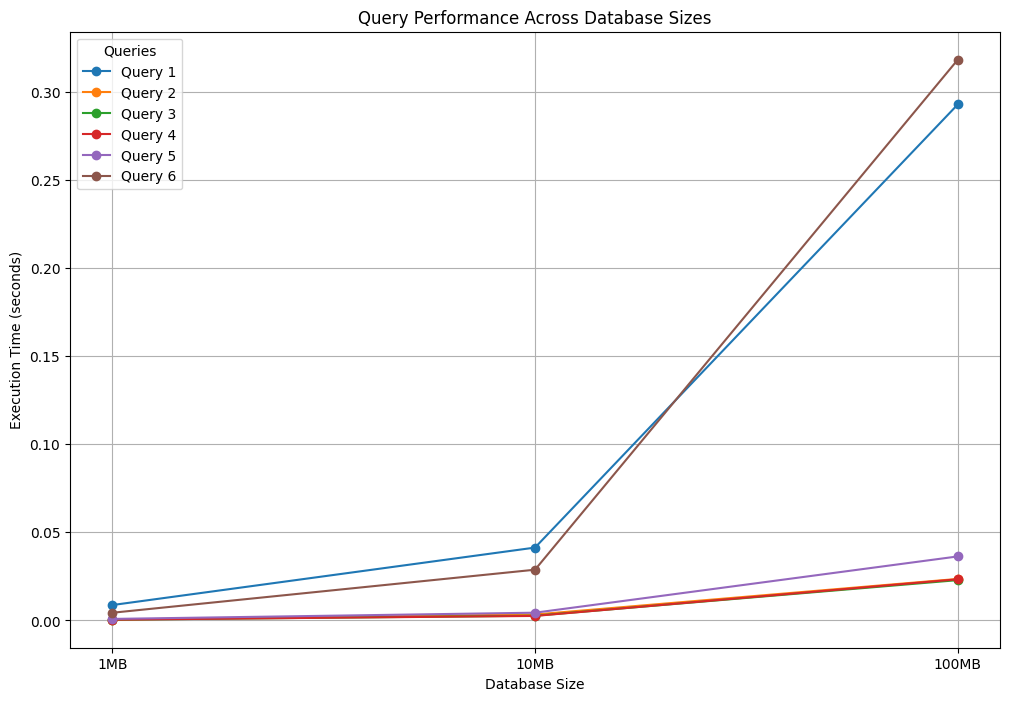

In [24]:
import sqlite3
import time
import matplotlib.pyplot as plt

# Paths to SQLite databases
db_files = {
    "1MB": "/Users/hrushitha/Desktop/dbdesignproj2/salary_data_1MB.db",
    "10MB": "/Users/hrushitha/Desktop/dbdesignproj2/salary_data_10MB.db",
    "100MB": "/Users/hrushitha/Desktop/dbdesignproj2/salary_data_100MB.db"
}

# Path to the queries text file
queries_file = "/Users/hrushitha/Desktop/dbdesignproj2/queries.txt"

# Function to load queries from a text file
def load_queries_from_file(file_path):
    queries = {}
    with open(file_path, 'r') as file:
        content = file.read()
        blocks = content.strip().split('\n\n')
        for block in blocks:
            lines = block.split('\n')
            query_name = lines[0].split(":")[0]  # Extract only "Query 1", "Query 2", etc.
            query_sql = '\n'.join(lines[1:])
            queries[query_name] = query_sql
    return queries

# Load queries from the text file
queries = load_queries_from_file(queries_file)

# Measure execution time and store results
results = {query_name: [] for query_name in queries}

print("\n--- Query Execution Times ---")
for db_size, db_path in db_files.items():
    conn = sqlite3.connect(db_path)
    cursor = conn.cursor()
    print(f"\nRunning queries on {db_size} database:")
    
    for query_name, query in queries.items():
        start_time = time.time()
        cursor.execute(query)
        cursor.fetchall()  # Ensure the query runs completely
        execution_time = time.time() - start_time
        results[query_name].append((db_size, execution_time))
        print(f"{query_name} on {db_size}: {execution_time:.4f} seconds")
    
    conn.close()

# Plot the results
plt.figure(figsize=(12, 8))

for query_name, timings in results.items():
    sizes = [size for size, _ in timings]
    times = [time for _, time in timings]
    plt.plot(sizes, times, marker='o', label=query_name)

plt.title("Query Performance Across Database Sizes")
plt.xlabel("Database Size")
plt.ylabel("Execution Time (seconds)")
plt.legend(title="Queries", loc="upper left")
plt.grid(True)
plt.show()


PERFORMANCE TRENDS

Execution Time Scaling:
Query runtimes increase predictably with database size. For instance:
Query 1: 0.0087s (1MB) → 0.0413s (10MB) → 0.2928s (100MB)
Query 6: 0.0043s (1MB) → 0.0288s (10MB) → 0.3182s (100MB)
This trend demonstrates that the schema is scalable and performs well even for large datasets.

Efficiency:
Runtimes for smaller databases (e.g., 1MB) are negligible for all queries.
The runtime difference between smaller and larger databases highlights the importance of proper schema design for handling larger datasets.


CONCLUSION

The project successfully demonstrates:

The ability to normalize a dataset into an efficient 3NF schema.
Validation of data integrity and relationships across tables.
Execution of complex queries across datasets of increasing sizes.
Performance trends and scalability of the schema design.